In [1]:
from pynq import Overlay
from pynq import allocate
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt 
import time

ol = Overlay("/home/xilinx/jupyter_notebooks/overlays/DarkEnhance/DarkEnhance_wrapper.bit")

cdma = ol.axi_cdma_0
gpio0 = ol.axi_gpio_0
gpio1 = ol.axi_gpio_1
gpio2 = ol.axi_gpio_2
gpio3 = ol.axi_gpio_3

In [2]:
def cdma_transfer(src_phys, dst_phys, size_bytes):
    CDMA_SR = 0x04
    CDMA_SA = 0x18
    CDMA_DA = 0x20
    CDMA_BTT = 0x28
    
    status = cdma.read(CDMA_SR)
    if (status & 0x70) != 0:
        print(f"警告: CDMA 處於錯誤狀態 (SR={hex(status)})。嘗試重置...")
        cdma.write(0x00, 0x4)
        while (cdma.read(CDMA_SR) & 0x02) == 0: pass

    cdma.write(CDMA_SA, src_phys)
    cdma.write(CDMA_DA, dst_phys)
    cdma.write(CDMA_BTT, size_bytes)

    while True:
        status = cdma.read(CDMA_SR)
        if (status & 0x02) != 0:
            break
        if (status & 0x70) != 0:
            raise RuntimeError(f"CDMA 傳輸錯誤！Status Register: {hex(status)}")

def PL_restart():
    gpio0.channel1.write(0x0, 0x1)
    time.sleep(0.001)
    gpio0.channel1.write(0x1, 0x1)
    time.sleep(0.001)
    gpio0.channel1.write(0x0, 0x1)
    
def PL_enable():
    gpio0.channel2.write(0x1, 0x1)

def PL_disable():
    gpio0.channel2.write(0x0, 0x1)
    
def transition_end():
    gpio1.channel1.write(0x1, 0x1)

def transitioning():
    gpio1.channel1.write(0x0, 0x1)
    
def ack():
    return gpio2.channel1.read()

def vaild():
    return gpio2.channel2.read()

def done():
    return gpio3.channel1.read()

In [3]:
IMG_W, IMG_H = 512, 512
CHANNELS = 4
SPLIT_NUM = 8
PADDING_ROWS = 1

core_height = IMG_H // SPLIT_NUM 
transfer_height = core_height + (PADDING_ROWS * 2) 
transfer_pixels = transfer_height * IMG_W
transfer_bytes = transfer_pixels * CHANNELS

print(f"核心高度: {core_height}, 傳輸高度: {transfer_height}")
print(f"每次傳輸大小: {transfer_bytes} bytes")

image_path = "input.jpg"
original_img = Image.open(image_path).convert('RGBA')
original_img = original_img.resize((IMG_W, IMG_H))

full_img_np = np.array(original_img)
final_result = np.zeros((IMG_H, IMG_W, CHANNELS), dtype=np.uint8)

try:
    input_buffer.freebuffer()
    output_buffer.freebuffer()
except NameError:
    pass # 第一次執行時變數不存在，忽略

input_buffer = allocate(shape=(transfer_pixels * CHANNELS,), dtype=np.uint8)
output_buffer = allocate(shape=(transfer_pixels * CHANNELS,), dtype=np.uint8)

print(f"Input Buffer Phys Addr: {hex(input_buffer.physical_address)}")

PL_INPUT_ADDR_BASE  = 0x40000000 
PL_OUTPUT_ADDR_BASE = 0x42000000

print("開始重疊分批處理...")
start_total = time.time()

PL_disable()

for i in range(SPLIT_NUM):
    PL_restart()
    
    core_start = i * core_height
    core_end = (i + 1) * core_height
    
    if i == 0:
        top_padding = full_img_np[0:PADDING_ROWS, :, :]
    else:
        top_padding = full_img_np[core_start-PADDING_ROWS : core_start, :, :]
        
    core_data = full_img_np[core_start : core_end, :, :]
    
    if i == SPLIT_NUM - 1:
        bottom_padding = full_img_np[IMG_H-PADDING_ROWS:IMG_H, :, :]
    else:
        bottom_padding = full_img_np[core_end : core_end+PADDING_ROWS, :, :]
        
    combined_data = np.vstack((top_padding, core_data, bottom_padding))
    
    input_buffer[:] = combined_data.flatten()
    input_buffer.flush()
    
    print(f"Batch {i+1}/{SPLIT_NUM}: Sending data (Rows {core_start}-{core_end})...")
    
    cdma_transfer(input_buffer.physical_address, PL_INPUT_ADDR_BASE, transfer_bytes)

    transitioning()
    PL_enable()

    timeout_limit = 3.0 
    start_wait = time.time()
    
    while True:
        done_val = done()
        if (done_val & 0x1) == 1:
            print(f"done")
            break

        if (time.time() - start_wait) > timeout_limit:
            raise TimeoutError("錯誤：PL 處理逾時！Done 訊號一直沒有拉高。")
        time.sleep(0.001)
    
    PL_disable()
    
    print(f"Batch {i+1}/{SPLIT_NUM}: Reading result...\n")
    cdma_transfer(PL_OUTPUT_ADDR_BASE, output_buffer.physical_address, transfer_bytes)
    output_buffer.invalidate()
    
    raw_result = np.array(output_buffer).reshape((transfer_height, IMG_W, CHANNELS))
    valid_result = raw_result[PADDING_ROWS:-PADDING_ROWS, :, :]
    
    final_result[core_start : core_end, :, :] = valid_result
    
end_total = time.time()
print(f"全部完成！耗時: {end_total - start_total:.4f} 秒")

核心高度: 64, 傳輸高度: 66
每次傳輸大小: 135168 bytes
Input Buffer Phys Addr: 0x15880000
開始重疊分批處理...
Batch 1/8: Sending data (Rows 0-64)...
done
Batch 1/8: Reading result...

Batch 2/8: Sending data (Rows 64-128)...
done
Batch 2/8: Reading result...

Batch 3/8: Sending data (Rows 128-192)...
done
Batch 3/8: Reading result...

Batch 4/8: Sending data (Rows 192-256)...
done
Batch 4/8: Reading result...

Batch 5/8: Sending data (Rows 256-320)...
done
Batch 5/8: Reading result...

Batch 6/8: Sending data (Rows 320-384)...
done
Batch 6/8: Reading result...

Batch 7/8: Sending data (Rows 384-448)...
done
Batch 7/8: Reading result...

Batch 8/8: Sending data (Rows 448-512)...
done
Batch 8/8: Reading result...

全部完成！耗時: 0.0909 秒


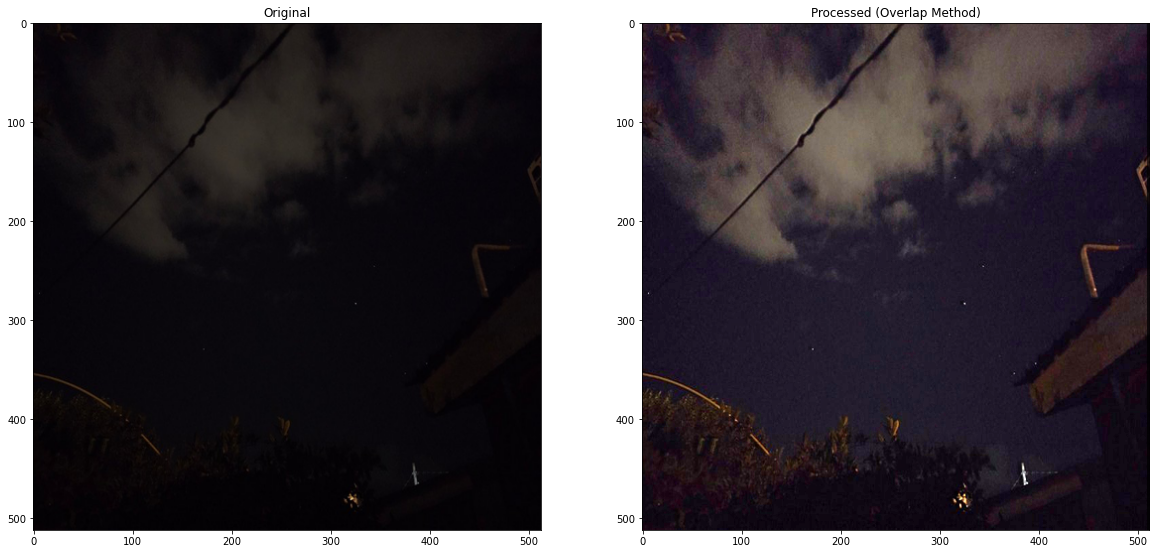

In [4]:
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(full_img_np)

plt.subplot(1, 2, 2)
plt.title("Processed (Overlap Method)")
plt.imshow(final_result[:, :, 0:3])
plt.show()

input_buffer.freebuffer()
output_buffer.freebuffer()